# 2 · Exploratory data analysis — Kerala daily rainfall

What the data looks like before any modelling, and what each property implies for
the super-resolution task. Runs on `paired_data.npz`, so run
`01_data_pipeline.ipynb` first.

Six questions:

| § | Question | Why it matters |
|---|---|---|
| 1 | How is daily rainfall distributed? | decides the transform |
| 2 | When does it rain? | two monsoons, very different |
| 3 | Where does it rain? | the orographic gradient the model must learn |
| 4 | How much does it vary year to year? | is the val/test split representative? |
| 5 | What does 0.25° averaging destroy? | the size of the problem |
| 6 | How far does rainfall correlate in space? | is 5× recovery even feasible? |

Figures are written to `figures/eda_*.png`.

In [1]:
import warnings
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

CWD = Path.cwd()
PROJECT = CWD.parent if CWD.name == "notebooks" else CWD
DATA = PROJECT / "Downscaling"
FIGURES = PROJECT / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

FACTOR = 5

# blocks that fall entirely outside the mask are all-NaN by design;
# nanstd/nanmean warn on those and the NaN result is what we want.
warnings.filterwarnings("ignore", message="Degrees of freedom <= 0")
warnings.filterwarnings("ignore", message="Mean of empty slice")

# shared plot tokens — same as the diagnostics figure, so the project reads as one set
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#b8b7b0"
BLUE, ORANGE, SURFACE, GRID = "#2a78d6", "#eb6834", "#fcfcfb", "#e6e5df"
RAIN = plt.get_cmap("YlGnBu").copy()
RAIN.set_bad("#f4f3f0")


def style(ax, ygrid=True):
    ax.set_facecolor(SURFACE)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(GRID)
    ax.tick_params(colors=INK2, labelsize=9, length=3)
    if ygrid:
        ax.grid(axis="y", color=GRID, lw=0.8)
        ax.set_axisbelow(True)
    return ax


def bare_map(ax):
    ax.set_aspect("equal")
    ax.set_xlim(74.8, 77.5)
    ax.set_ylim(8.2, 12.8)
    ax.set_xticks([]); ax.set_yticks([])
    return ax

In [2]:
d = np.load(DATA / "paired_data.npz", allow_pickle=True)
hr, lr = d["hr"], d["lr"]
mask_hr, mask_lr = d["mask_hr"], d["mask_lr"]
dates = d["dates"]
lat_hr, lon_hr = d["lat_hr"], d["lon_hr"]
mask = mask_hr.astype(bool)

state = gpd.read_file(DATA / "state.geojson")

years = dates.astype("datetime64[Y]").astype(int) + 1970
months = dates.astype("datetime64[M]").astype(int) % 12 + 1
doy = (dates - dates.astype("datetime64[Y]")).astype("timedelta64[D]").astype(int) + 1

vals = hr[:, mask]                       # (days, valid cells) — every rainfall observation
daily_mean = vals.mean(axis=1)           # domain-mean rainfall per day

print(f"grid            {mask_hr.shape[0]}×{mask_hr.shape[1]} at 0.05°  "
      f"({mask.sum()} cells inside Kerala, {100*mask.mean():.0f}% of the box)")
print(f"extent          {lat_hr.min():.2f}–{lat_hr.max():.2f}°N, {lon_hr.min():.2f}–{lon_hr.max():.2f}°E")
print(f"period          {str(dates[0])[:10]} to {str(dates[-1])[:10]}  ({len(dates):,} days)")
print(f"gaps            {len(np.unique(dates)) != len(dates) or np.any(np.diff(dates).astype('timedelta64[D]').astype(int) != 1)}")
print(f"observations    {vals.size/1e6:.1f} million cell-days")
print(f"missing values  {np.isnan(vals).sum()}")

grid            90×50 at 0.05°  (1443 cells inside Kerala, 32% of the box)
extent          8.27–12.72°N, 74.88–77.33°E
period          1996-01-01 to 2025-12-31  (10,958 days)
gaps            False
observations    15.8 million cell-days
missing values  0


## 1 · How is daily rainfall distributed?

Two properties dominate everything downstream: **most cell-days are exactly zero**, and
the wet tail is **extremely long**.

In [3]:
zero_frac = float((vals == 0).mean())
wet = vals[vals >= 1]
skew = float(((vals - vals.mean()) ** 3).mean() / vals.std() ** 3)

print(f"exactly zero      {100*zero_frac:.1f}% of all cell-days")
print(f"≥ 1 mm            {100*(vals >= 1).mean():.1f}%")
print(f"≥ 50 mm           {100*(vals >= 50).mean():.2f}%")
print(f"≥ 100 mm          {100*(vals >= 100).mean():.2f}%")
print()
print(f"mean              {vals.mean():.2f} mm/day")
print(f"median            {np.median(vals):.2f} mm/day   ← the median day is bone dry")
print(f"p90 / p99 / max   {np.percentile(vals,90):.1f} / {np.percentile(vals,99):.1f} / {vals.max():.1f} mm/day")
print(f"skewness          {skew:.1f}")
print(f"wet days only     mean {wet.mean():.1f}, median {np.median(wet):.1f} mm/day")

exactly zero      66.5% of all cell-days
≥ 1 mm            33.2%
≥ 50 mm           3.29%
≥ 100 mm          0.59%

mean              7.73 mm/day
median            0.00 mm/day   ← the median day is bone dry
p90 / p99 / max   25.3 / 83.7 / 578.4 mm/day
skewness          4.5
wet days only     mean 23.3, median 15.9 mm/day


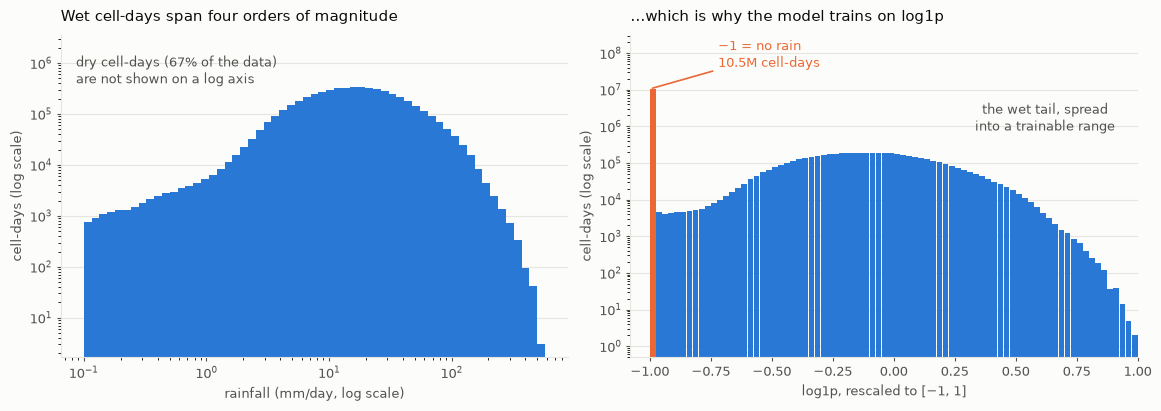

In [4]:
# NOTE: pass a 1-D array to hist(). A 2-D (days, cells) array is read as one
# dataset per column, which silently draws 1,443 overlaid histograms.
flat = vals.ravel()

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0), facecolor=SURFACE, constrained_layout=True)

ax = style(axes[0])
bins = np.logspace(np.log10(0.1), np.log10(flat.max()), 60)
ax.hist(flat[flat > 0], bins=bins, color=BLUE, edgecolor="none")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_ylim(top=ax.get_ylim()[1] * 6)
ax.set_xlabel("rainfall (mm/day, log scale)", fontsize=9.5, color=INK2)
ax.set_ylabel("cell-days (log scale)", fontsize=9.5, color=INK2)
ax.set_title("Wet cell-days span four orders of magnitude", fontsize=11, color=INK, pad=10, loc="left")
ax.text(0.03, 0.94, f"dry cell-days ({100*zero_frac:.0f}% of the data)\nare not shown on a log axis",
        transform=ax.transAxes, ha="left", va="top", fontsize=9.5, color=INK2)

ax = style(axes[1])
scale = float(np.log1p(flat.max()))
t = np.log1p(flat) / scale * 2 - 1
counts, edges = np.histogram(t, bins=80)
centres = (edges[:-1] + edges[1:]) / 2
cols = [ORANGE] + [BLUE] * (len(counts) - 1)      # first bin holds the dry mass
ax.bar(centres, np.maximum(counts, 0.5), width=(edges[1] - edges[0]) * 0.95,
       color=cols, edgecolor="none")
ax.set_yscale("log")
ax.set_ylim(0.5, counts.max() * 30)
ax.set_xlim(-1.08, 1.0)
ax.set_xlabel("log1p, rescaled to [−1, 1]", fontsize=9.5, color=INK2)
ax.set_ylabel("cell-days (log scale)", fontsize=9.5, color=INK2)
ax.set_title("…which is why the model trains on log1p", fontsize=11, color=INK, pad=10, loc="left")
ax.annotate(f"−1 = no rain\n{counts[0]/1e6:.1f}M cell-days",
            xy=(-1, counts[0]), xytext=(-0.72, counts[0] * 4),
            fontsize=9.5, color=ORANGE,
            arrowprops=dict(arrowstyle="-", color=ORANGE, lw=1.2))
ax.text(0.62, counts[1:].max() * 4, "the wet tail, spread\ninto a trainable range",
        fontsize=9.5, color=INK2, ha="center")

fig.savefig(FIGURES / "eda_distribution.png", dpi=160, facecolor=SURFACE, bbox_inches="tight")
plt.show()

**What this means for the model.** Two-thirds of the target is a point mass at zero and
the rest spans four orders of magnitude, so raw-space L2 training would be dominated
entirely by a handful of extreme cells. The `log1p → [−1, 1]` transform in
`03_model.ipynb` §1 compresses that tail into something a network can fit, and mapping
"no rain" to exactly −1 gives the generator a clean value to output over dry cells and
outside the mask.

It also explains the evaluation result: RMSE and R² are computed in mm space, where
the tail dominates, which is precisely why they reward a blurred prediction that hedges
toward the mean. Wet-day CSI, computed after thresholding, does not.

## 2 · When does it rain?

Kerala has **two** monsoons — the southwest (Jun–Sep) and the northeast (Oct–Dec) — and
they behave differently.

In [5]:
clim_doy = np.array([daily_mean[doy == k].mean() for k in range(1, 367)])
monthly = np.array([daily_mean[months == m].mean() for m in range(1, 13)])
share = np.array([daily_mean[months == m].sum() for m in range(1, 13)])
share = share / share.sum()

sw, ne = slice(5, 9), slice(9, 12)   # Jun-Sep, Oct-Dec
print(f"SW monsoon (Jun–Sep)  {100*share[sw].sum():.0f}% of annual rainfall")
print(f"NE monsoon (Oct–Dec)  {100*share[ne].sum():.0f}%")
print(f"Jan–Mar               {100*share[:3].sum():.0f}%")
print(f"\nwettest month  {'JFMAMJJASOND'[monthly.argmax()]}{monthly.argmax()+1} at {monthly.max():.1f} mm/day")
print(f"driest month   {'JFMAMJJASOND'[monthly.argmin()]}{monthly.argmin()+1} at {monthly.min():.2f} mm/day")
print(f"ratio          {monthly.max()/monthly.min():.0f}×")

SW monsoon (Jun–Sep)  63% of annual rainfall
NE monsoon (Oct–Dec)  20%
Jan–Mar               3%

wettest month  J6 at 18.6 mm/day
driest month   J1 at 0.53 mm/day
ratio          35×


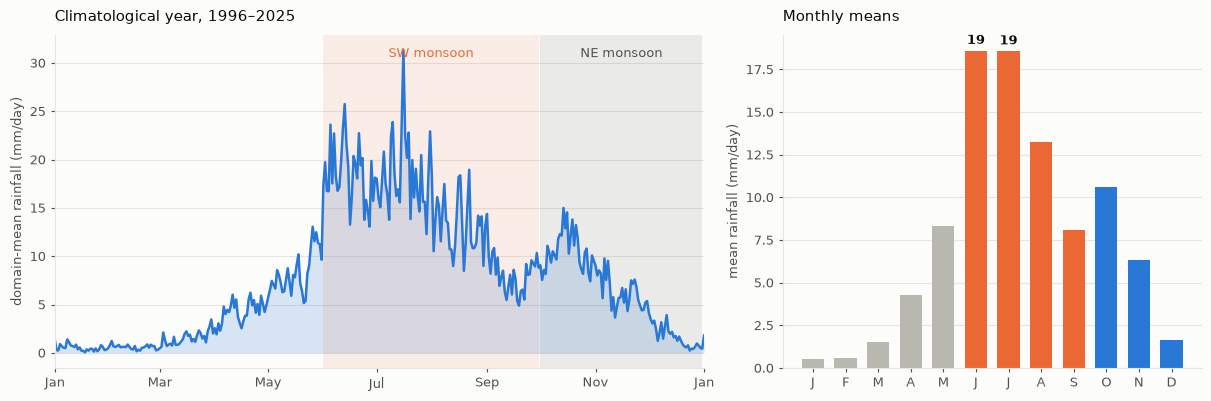

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.9), facecolor=SURFACE,
                         gridspec_kw={"width_ratios": [1.55, 1]}, constrained_layout=True)

ax = style(axes[0])
ax.fill_between(range(1, 367), 0, clim_doy, color=BLUE, alpha=0.18, lw=0)
ax.plot(range(1, 367), clim_doy, lw=1.8, color=BLUE)
for lo, hi, label, col in [(152, 273, "SW monsoon", ORANGE), (274, 365, "NE monsoon", INK2)]:
    ax.axvspan(lo, hi, color=col, alpha=0.10, lw=0)
    ax.text((lo + hi) / 2, ax.get_ylim()[1] * 0.93, label, ha="center", fontsize=9.5, color=col)
ax.set_xlim(1, 366)
ax.set_xticks([1, 60, 121, 182, 244, 305, 366])
ax.set_xticklabels(["Jan", "Mar", "May", "Jul", "Sep", "Nov", "Jan"])
ax.set_ylabel("domain-mean rainfall (mm/day)", fontsize=9.5, color=INK2)
ax.set_title("Climatological year, 1996–2025", fontsize=11, color=INK, pad=10, loc="left")

ax = style(axes[1])
cols = [ORANGE if 5 <= i < 9 else BLUE if i >= 9 else MUTED for i in range(12)]
ax.bar(range(1, 13), monthly, color=cols, width=0.68)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(list("JFMAMJJASOND"), fontsize=9)
ax.set_ylabel("mean rainfall (mm/day)", fontsize=9.5, color=INK2)
ax.set_title("Monthly means", fontsize=11, color=INK, pad=10, loc="left")
for m in (5, 6):
    ax.text(m + 1, monthly[m] + 0.4, f"{monthly[m]:.0f}", ha="center", fontsize=9,
            color=INK, fontweight="bold")

fig.savefig(FIGURES / "eda_seasonality.png", dpi=160, facecolor=SURFACE, bbox_inches="tight")
plt.show()

**What this means for the model.** June and July alone carry roughly a third of the
year, and the wettest month is about 35× the driest. Training on all 10,958 days without
weighting means most gradient steps come from near-dry days — which is one reason the
adversarial signal, whose job is texture on wet days, is slow to show up in a
pixel-metric validation curve.

It also makes the chronological split safe in a way a random split would not be: whole
years go to each partition, so every split sees complete monsoon cycles rather than
leaking neighbouring days of the same storm across the boundary.

## 3 · Where does it rain?

Kerala is a 550 km strip between the Arabian Sea and the Western Ghats. That
topography produces a steep orographic gradient across a very short distance — and it
is exactly the structure a downscaler has to reproduce.

In [7]:
clim = np.where(mask, hr.mean(axis=0) * 365.25, np.nan)          # mm/year
wet_freq = np.where(mask, (hr >= 1).mean(axis=0), np.nan)        # fraction of days ≥1mm
p99_map = np.where(mask, np.percentile(hr, 99, axis=0), np.nan)  # mm/day

print(f"annual rainfall   {np.nanmin(clim):.0f} to {np.nanmax(clim):.0f} mm/yr "
      f"— a {np.nanmax(clim)/np.nanmin(clim):.1f}× range across one small state")
print(f"domain mean       {np.nanmean(clim):.0f} mm/yr\n")
print("west → east (the Ghats gradient):")
for a, b in [(74.8, 75.4), (75.4, 76.0), (76.0, 76.6), (76.6, 77.4)]:
    sel = (lon_hr >= a) & (lon_hr < b)
    if np.isfinite(clim[:, sel]).any():
        print(f"  {a:.1f}–{b:.1f}°E   {np.nanmean(clim[:, sel]):.0f} mm/yr")

annual rainfall   936 to 4001 mm/yr — a 4.3× range across one small state
domain mean       2823 mm/yr

west → east (the Ghats gradient):
  74.8–75.4°E   3790 mm/yr
  75.4–76.0°E   3278 mm/yr
  76.0–76.6°E   2845 mm/yr
  76.6–77.4°E   2455 mm/yr


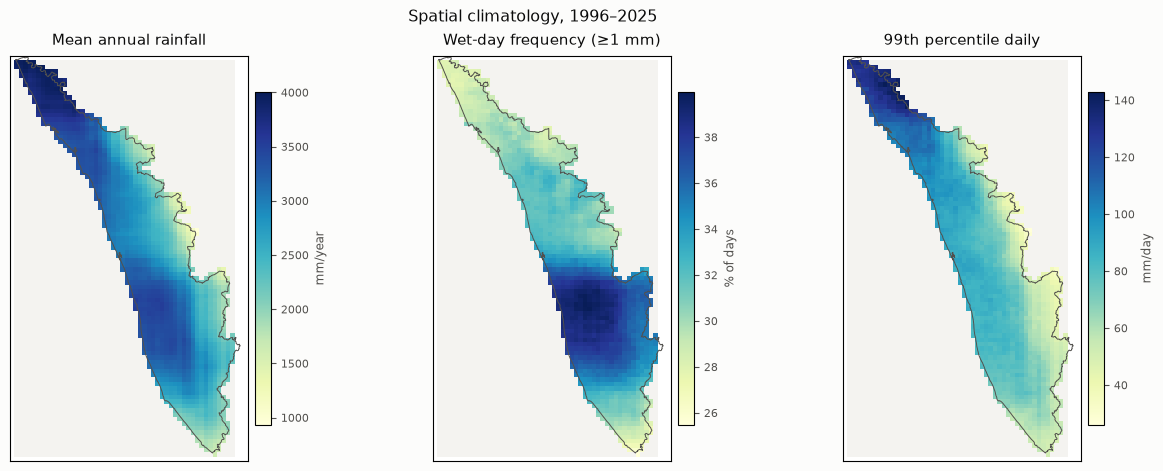

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 4.6), facecolor=SURFACE, constrained_layout=True)

panels = [("Mean annual rainfall", clim, "mm/year", None),
          ("Wet-day frequency (≥1 mm)", wet_freq * 100, "% of days", None),
          ("99th percentile daily", p99_map, "mm/day", None)]

for ax, (title, field, unit, _) in zip(axes, panels):
    pcm = ax.pcolormesh(lon_hr, lat_hr, field, cmap=RAIN, shading="auto")
    state.boundary.plot(ax=ax, color="#52514e", linewidth=0.7)
    bare_map(ax)
    ax.set_title(title, fontsize=10.5, color=INK, pad=8)
    cb = fig.colorbar(pcm, ax=ax, shrink=0.82, pad=0.02)
    cb.set_label(unit, fontsize=8.5, color=INK2)
    cb.ax.tick_params(labelsize=8, colors=INK2)

fig.suptitle("Spatial climatology, 1996–2025", fontsize=11.5, color=INK)
fig.savefig(FIGURES / "eda_climatology.png", dpi=160, facecolor=SURFACE, bbox_inches="tight")
plt.show()

**What this means for the model.** Wettest to driest cell is a **4.3× range**, and the
west-to-east drop is monotonic and sharp — coastal cells get about 3,800 mm/yr, eastern
cells about 2,450. At 0.25° that whole gradient is smeared across roughly four grid
boxes.

This is the case for the project in one image: the fine-scale field is not noise on top
of the coarse field, it is a systematic, topography-locked pattern that repeats every
year. A model can learn it.

Note too that the three panels disagree about *where* Kerala is wettest, and the
disagreement is informative:

| | peak | coastal share of top 5% of cells |
|---|---|---|
| Mean annual rainfall | 12.5°N 75.2°E — far northwest coast | 100% |
| Wet-day frequency | 10.0°N 76.6°E — south-central interior | 0% |
| 99th percentile daily | 12.5°N 75.3°E — northwest coast | 100% |

Totals and extremes peak together on the **northern coast**, while the frequency of
rain peaks **inland in the south**. So the north coast rains less often but far harder,
and the southern interior rains more often but more gently. "Downscale rainfall" is
really two different spatial problems — intensity and occurrence — layered on each
other, which is exactly why §6 of `03_model.ipynb` scores them separately.

## 4 · How much does it vary year to year?

The relevant question for interpreting results: are the validation and test years
**typical**, or did the split hand the model an unusual period?

In [9]:
annual = np.array([hr[years == y][:, mask].sum(axis=0).mean() for y in range(1996, 2026)])
yr = np.arange(1996, 2026)

groups = {"train 1996–2018": yr <= 2018,
          "val 2019–2021": (yr >= 2019) & (yr <= 2021),
          "test 2022–2025": yr >= 2022}

print(f"record mean   {annual.mean():.0f} mm/yr  (sd {annual.std():.0f}, "
      f"{100*annual.std()/annual.mean():.0f}% of the mean)")
print(f"wettest year  {yr[annual.argmax()]}  {annual.max():.0f} mm")
print(f"driest year   {yr[annual.argmin()]}  {annual.min():.0f} mm\n")
for name, sel in groups.items():
    print(f"{name:18s} {annual[sel].mean():.0f} mm/yr   {100*(annual[sel].mean()/annual.mean()-1):+.1f}% vs record")

record mean   2823 mm/yr  (sd 355, 13% of the mean)
wettest year  2007  3404 mm
driest year   2016  1785 mm

train 1996–2018    2789 mm/yr   -1.2% vs record
val 2019–2021      3010 mm/yr   +6.7% vs record
test 2022–2025     2874 mm/yr   +1.8% vs record


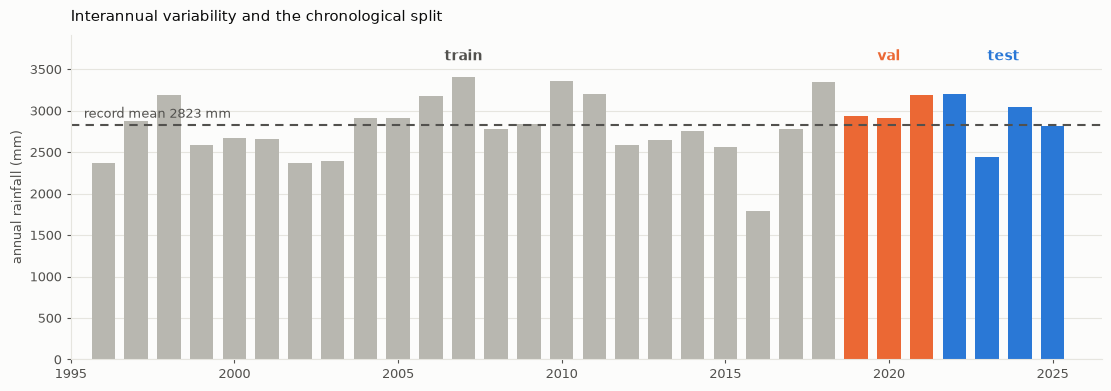

In [10]:
fig, ax = plt.subplots(figsize=(11, 3.8), facecolor=SURFACE, constrained_layout=True)
style(ax)

cols = [MUTED if y <= 2018 else ORANGE if y <= 2021 else BLUE for y in yr]
ax.bar(yr, annual, color=cols, width=0.72)
ax.axhline(annual.mean(), ls=(0, (4, 3)), lw=1.5, color=INK2)
ax.text(1995.4, annual.mean() * 1.02, f"record mean {annual.mean():.0f} mm", va="bottom",
        ha="left", fontsize=9, color=INK2)

for name, sel, col in [("train", yr <= 2018, MUTED),
                       ("val", (yr >= 2019) & (yr <= 2021), ORANGE),
                       ("test", yr >= 2022, BLUE)]:
    ax.text(yr[sel].mean(), annual.max() * 1.06, name, ha="center", fontsize=10,
            color=col if col != MUTED else INK2, fontweight="bold")

ax.set_ylim(0, annual.max() * 1.15)
ax.set_xlim(1995, 2026.5)
ax.set_ylabel("annual rainfall (mm)", fontsize=9.5, color=INK2)
ax.set_title("Interannual variability and the chronological split", fontsize=11,
             color=INK, pad=10, loc="left")

fig.savefig(FIGURES / "eda_interannual.png", dpi=160, facecolor=SURFACE, bbox_inches="tight")
plt.show()

**What this means for the model — and it is worth knowing.** The test years are close
to typical (**+1.8%**), so the reported test metrics are not flattered or penalised by an
unusual period. Good.

The **validation years are +6.7% wetter than the record**, though, and that is where the
checkpoint gets selected. Selection therefore happens on a period with systematically
more wet days than the model will face at test time — a mild bias toward whichever epoch
handles heavy rain best. It is a small effect next to the log-space consistency bug
(`docs/REPORT.md` finding 1), but if the split is ever revisited, three *average* years
would be a better validation set than the three wettest-leaning ones available.

Note also 2016 (1,785 mm) and 2018 — the year of the Kerala floods — sitting on opposite
extremes just two years apart, both inside the training period. The model sees the full
range, which is the main thing.

## 5 · What does 0.25° averaging actually destroy?

This is the project in one number. Each 0.25° cell is a 5×5 average of 25 real 0.05°
cells; the **within-block standard deviation** is the variability that averaging throws
away, and that the model has to put back.

In [11]:
blocks = np.where(mask, hr, np.nan).reshape(-1, 18, FACTOR, 10, FACTOR)
with np.errstate(invalid="ignore"):
    blk_std = np.nanstd(blocks, axis=(2, 4))
    blk_mean = np.nanmean(blocks, axis=(2, 4))

ok = np.isfinite(blk_std) & np.isfinite(blk_mean) & (blk_mean > 0)
edges = [0, 1, 5, 20, 50, np.inf]
rows = []
for lo, hi in zip(edges[:-1], edges[1:]):
    s = ok & (blk_mean >= lo) & (blk_mean < hi)
    if s.sum():
        rows.append((lo, hi, blk_std[s].mean(), 100 * (blk_std[s] / blk_mean[s]).mean(), s.sum()))

print(f"overall mean within-block std   {np.nanmean(blk_std):.2f} mm/day")
print(f"mean within-block CV            {np.nanmean(blk_std[ok]/blk_mean[ok]):.2f}\n")
print(f"{'block mean (mm/day)':>22}   {'within-block std':>16}   {'as % of mean':>12}   {'n':>10}")
for lo, hi, s, pct, n in rows:
    label = f"{lo:.0f}–{hi:.0f}" if np.isfinite(hi) else f"{lo:.0f}+"
    print(f"{label:>22}   {s:16.2f}   {pct:11.0f}%   {n:10,}")

overall mean within-block std   2.67 mm/day
mean within-block CV            0.86

   block mean (mm/day)   within-block std   as % of mean            n
                   0–1               1.44           315%       33,092
                   1–5               3.52           142%       80,409
                  5–20               5.10            50%      158,786
                 20–50               8.81            29%       81,995
                   50+              16.86            22%       24,828


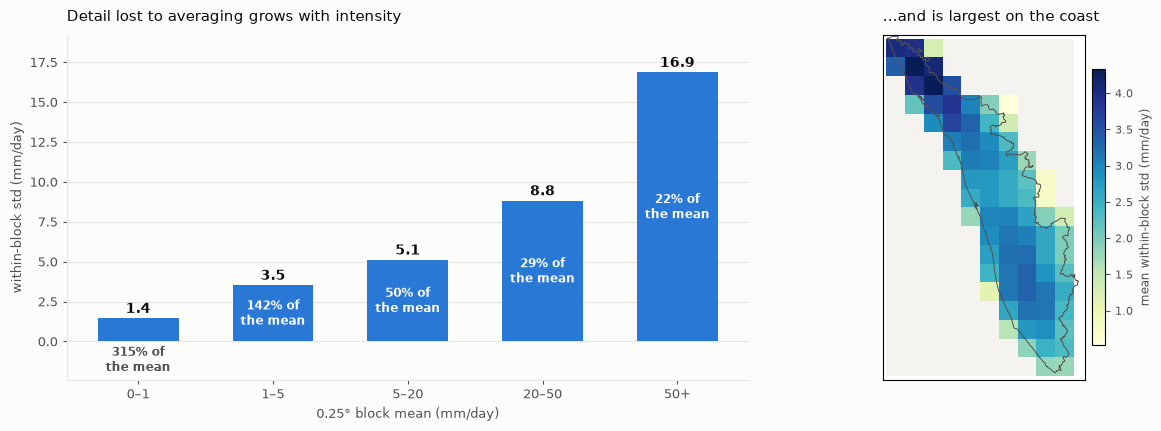

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), facecolor=SURFACE,
                         gridspec_kw={"width_ratios": [2.1, 1]}, constrained_layout=True)

ax = style(axes[0])
ax.bar(range(len(rows)), [r[2] for r in rows], color=BLUE, width=0.6)
for i, (lo, hi, s, pct, n) in enumerate(rows):
    ax.text(i, s + 0.35, f"{s:.1f}", ha="center", fontsize=10, color=INK, fontweight="bold")
    # the % label only fits inside a tall enough bar; short bars get it underneath
    inside = s > 3
    ax.text(i, s / 2 if inside else -1.15, f"{pct:.0f}% of\nthe mean", ha="center",
            va="center", fontsize=8.5, fontweight="bold",
            color="white" if inside else INK2)
ax.set_ylim(-2.4, max(r[2] for r in rows) * 1.14)
ax.set_xticks(range(len(rows)))
ax.set_xticklabels(["0–1", "1–5", "5–20", "20–50", "50+"], fontsize=9)
ax.set_xlabel("0.25° block mean (mm/day)", fontsize=9.5, color=INK2)
ax.set_ylabel("within-block std (mm/day)", fontsize=9.5, color=INK2)
ax.set_title("Detail lost to averaging grows with intensity", fontsize=11, color=INK,
             pad=10, loc="left")

ax = axes[1]
lost = np.full(mask_lr.shape, np.nan)
lost[mask_lr] = np.nanmean(blk_std, axis=0)[mask_lr]
lat_lr, lon_lr = d["lat_lr"], d["lon_lr"]
pcm = ax.pcolormesh(lon_lr, lat_lr, lost, cmap=RAIN, shading="auto")
state.boundary.plot(ax=ax, color="#52514e", linewidth=0.7)
bare_map(ax)
ax.set_title("…and is largest on the coast", fontsize=11, color=INK, pad=10, loc="left")
cb = fig.colorbar(pcm, ax=ax, shrink=0.8, pad=0.02)
cb.set_label("mean within-block std (mm/day)", fontsize=8.5, color=INK2)
cb.ax.tick_params(labelsize=8, colors=INK2)

fig.savefig(FIGURES / "eda_subgrid.png", dpi=160, facecolor=SURFACE, bbox_inches="tight")
plt.show()

**What this means for the model.** On a block averaging 5–20 mm/day, the cells inside it
differ by about **5 mm — half the block mean**. On the wettest blocks the spread reaches
17 mm. Averaged over everything, the within-block coefficient of variation is **0.86**:
the sub-grid signal is roughly as large as the signal that survives.

So this is not a cosmetic task. A model that outputs the block mean everywhere — which
is exactly what nearest-upsampling does — is discarding a quantity comparable in size to
what it keeps. That is the number the evaluation in `03_model.ipynb` §6 is measuring
against: the GAN recovers about 65% of it, bilinear about 37%, nearest none.

## 6 · How far does rainfall correlate in space?

Section 5 says there is a lot of sub-grid signal. This section asks the harder question:
is any of it **predictable** from the coarse field, or is it noise?

If rainfall decorrelated completely over one 0.25° block width (~28 km), the sub-grid
detail would be unrecoverable in principle and the whole approach would be doomed. So
measure the correlation between every pair of cells over the full 30-year record and bin
it by separation distance.

In [13]:
rng = np.random.default_rng(0)
ii, jj = np.where(mask)
sub = rng.choice(len(ii), size=700, replace=False)   # 700 cells → 244,650 pairs

series = hr[:, mask][:, sub].T                       # (cells, days)
corr = np.corrcoef(series)

la, lo = lat_hr[ii[sub]], lon_hr[jj[sub]]
km_per_deg_lon = 111.32 * np.cos(np.deg2rad(la.mean()))
dx = (lo[:, None] - lo[None, :]) * km_per_deg_lon
dy = (la[:, None] - la[None, :]) * 110.57
dist = np.sqrt(dx ** 2 + dy ** 2)

iu = np.triu_indices(len(sub), 1)
dd, cc = dist[iu], corr[iu]

bin_edges = np.arange(0, 320, 10)
centres = (bin_edges[:-1] + bin_edges[1:]) / 2
binned = np.array([cc[(dd >= a) & (dd < b)].mean() if ((dd >= a) & (dd < b)).sum() > 50 else np.nan
                   for a, b in zip(bin_edges[:-1], bin_edges[1:])])

BLOCK_KM = 0.25 * km_per_deg_lon   # one 0.25° block ≈ 27 km
r_block = float(cc[(dd >= BLOCK_KM - 3) & (dd <= BLOCK_KM + 3)].mean())
r_cell = float(cc[dd <= 6].mean())

print(f"{len(iu[0]):,} cell pairs from {len(sub)} sampled cells\n")
for a, b in [(0, 10), (10, 25), (25, 50), (50, 100), (100, 200), (200, 400)]:
    s = (dd >= a) & (dd < b)
    print(f"  {a:3d}–{b:3d} km   r = {cc[s].mean():.3f}   ({s.sum():,} pairs)")
print(f"\n  one 0.05° cell  (~5 km):   r ≈ {r_cell:.3f}")
print(f"  one 0.25° block (~{BLOCK_KM:.0f} km):  r ≈ {r_block:.3f}")

244,650 cell pairs from 700 sampled cells

    0– 10 km   r = 0.921   (1,237 pairs)
   10– 25 km   r = 0.833   (8,298 pairs)
   25– 50 km   r = 0.740   (20,917 pairs)
   50–100 km   r = 0.626   (53,853 pairs)
  100–200 km   r = 0.506   (80,206 pairs)
  200–400 km   r = 0.377   (72,865 pairs)

  one 0.05° cell  (~5 km):   r ≈ 0.934
  one 0.25° block (~27 km):  r ≈ 0.785


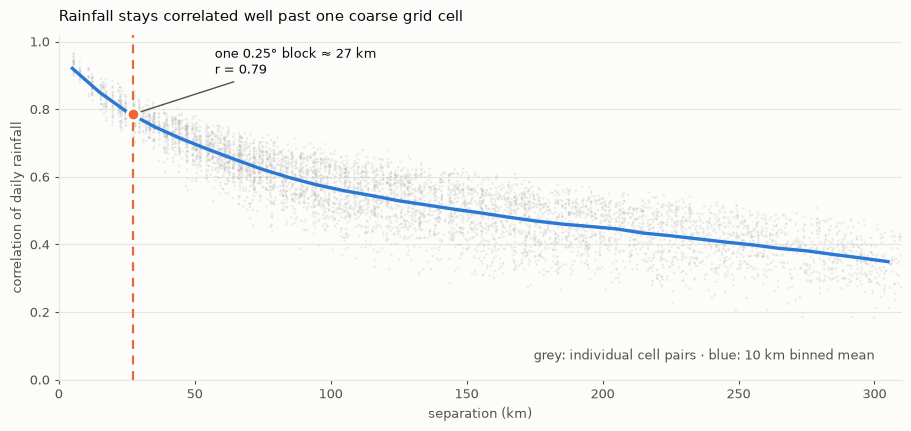

In [14]:
fig, ax = plt.subplots(figsize=(9, 4.2), facecolor=SURFACE, constrained_layout=True)
style(ax)

ax.scatter(dd[::37], cc[::37], s=3, color=MUTED, alpha=0.25, edgecolors="none", zorder=1)
ax.plot(centres, binned, lw=2.4, color=BLUE, zorder=3)

ax.axvline(BLOCK_KM, ls=(0, (4, 3)), lw=1.6, color=ORANGE, zorder=2)
ax.plot([BLOCK_KM], [r_block], "o", ms=9, color=ORANGE, mec=SURFACE, mew=2, zorder=4)
ax.annotate(f"one 0.25° block ≈ {BLOCK_KM:.0f} km\nr = {r_block:.2f}",
            xy=(BLOCK_KM, r_block), xytext=(BLOCK_KM + 30, r_block + 0.12),
            fontsize=9.5, color=INK, arrowprops=dict(arrowstyle="-", color=INK2, lw=1))

ax.set_xlim(0, 310)
ax.set_ylim(0, 1.02)
ax.set_xlabel("separation (km)", fontsize=9.5, color=INK2)
ax.set_ylabel("correlation of daily rainfall", fontsize=9.5, color=INK2)
ax.set_title("Rainfall stays correlated well past one coarse grid cell", fontsize=11,
             color=INK, pad=10, loc="left")
ax.text(300, 0.06, "grey: individual cell pairs · blue: 10 km binned mean",
        ha="right", fontsize=9, color=INK2)

fig.savefig(FIGURES / "eda_correlation.png", dpi=160, facecolor=SURFACE, bbox_inches="tight")
plt.show()

**What this means for the model — this is the feasibility check.** Correlation is
**0.92** between neighbouring 0.05° cells and still **0.78** across a full 0.25° block.
Rainfall decays smoothly with distance and does not decorrelate anywhere near the block
scale.

Two consequences pull in opposite directions, and both show up in the results:

- **The task is learnable.** Sub-grid detail is strongly tied to its surroundings, so a
  convolutional model with enough receptive field can infer a lot of it from the coarse
  field plus the systematic geography of section 3.
- **A blurry answer is a good answer, by pointwise metrics.** With r ≈ 0.78 across a
  block, simply repeating the block mean is already a strong predictor of each cell.
  That is why nearest-upsampling reaches RMSE 7.12 and R² 0.84 while inventing nothing
  at all, and why beating it on those metrics is much harder than it looks.

Which is the whole argument of `docs/REPORT.md` finding 4: on data this spatially
coherent, RMSE cannot distinguish a model that recovers structure from one that
declines to try.

## Summary — what the data says about the modelling choices

| Property | Value | Consequence |
|---|---|---|
| Zero-inflation | 67% of cell-days exactly 0 | `log1p` transform; −1 encodes "no rain" |
| Skewness | 4.5, max 578 mm/day | mm-space RMSE is tail-dominated |
| Seasonality | Jun–Jul = ⅓ of the year | most training batches are near-dry |
| Spatial range | 936 → 4,001 mm/yr (4.3×) | fine structure is systematic, not noise |
| Test years | +1.8% vs record | test metrics are not flattered |
| **Val years** | **+6.7% vs record** | **checkpoint selected on a wet-leaning period** |
| Within-block CV | 0.86 | discarded signal ≈ retained signal |
| Correlation at 28 km | 0.78 | task is learnable — but blur scores well |

Two of these are findings rather than background:

1. **The validation period is wetter than the record.** Checkpoint selection happens
   there, so it carries a mild bias toward epochs that handle heavy rain. Worth fixing
   whenever the split is revisited.
2. **High spatial coherence is why the baselines are so hard to beat on RMSE.** With
   r ≈ 0.78 across a coarse cell, the block mean is already a good pointwise guess.
   That reframes the headline result: the GAN is not underperforming on RMSE, it is
   being scored on a metric that this data makes nearly impossible to win honestly.

Full review in `docs/REPORT.md`.